In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs, load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import seaborn as sbn

from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier

## Ponavljanje: logistička regresija (2 klase)
- $(x^{(i)}, y^{(i)}), i=1,..,m$ trening podaci
- $x^{(i)} \in \mathbb{R}^{n}, y^{(i)} \in \{ -1,1 \}$
- Funkcija $h_{\theta}(x^{(i)}) = \sigma (\theta^T \cdot x^{(i)}) = P(y^{(i)} = 1 | x^{(i)};\theta)$
- Prva kriterijska funkcija (uz promjenu labela na 0 i 1 umjesto -1 i 1):
$$J(\theta) = \frac{1}{2m} \sum_{i=1}^m (h_{\theta}(x^{(i)}) - y^{(i)}) \rightarrow \min_{\theta}$$
- Problem ove funkcije što nije konveksna $\Rightarrow$ ne možemo primjeniti klasične optimizacijske algoritme koji bi optimizirali konveksne funkcije
- Druga kriterijska funkcija (koristimo vjerojatnost umjesto standardne interpretacije udaljenosti):
- IDEJA: želimo neku funkciju koja će maksimizirati vjerojatnost da je svaki podatak dobro klasificiran (engl. Likelihood Function, a cijeli problem se naziva engl. Maximum-Likelihood Problem)
$$ L(\theta|x) = J'(\theta) = \prod_{i=1}^{m}(P(y^{(i)} | x^{(i)}; \theta)) \rightarrow \max_{\theta} $$
- maksimiziranje produkta je teško pa funkciju "napadamo" logaritmom (ideja je razbiti produkt) i množimo s -1
$$ J(\theta) = -\log(J'(\theta)) = \sum_{i=1}^m -\log (P(y^{(i)} | x^{(i)}; \theta))$$
$$= \sum_{i=1}^m -\log (\sigma(y^{(i)} \theta^T x^{(i)})) $$
$$= \sum_{i=1}^m \log (1 + e^{-y^{(i)} \theta^T x^{(i)}}) \rightarrow \min_{\theta}$$
- primjenom gradijentne metode ili nekog drugog optimizacijskog algoritma učimo ovakvu funkciju.

Idemo se uvjeriti da možemo ovakvu funkciju optimizirati bez nekakvog algoritma nego samo optimizacijom!

### Gradijent kriterijske funkcije
Napomena: $\log$ označava prirodni logaritam (baza $e$), tj. $\log(x) = \ln(x)$.

Gradijent po $\theta$ iznosi:

$$
\nabla_\theta J(\theta) = \sum_{i=1}^m \frac{-y^{(i)} x^{(i)}}{1 + e^{y^{(i)} \theta^T x^{(i)}}}
$$

Koristeći sigmoid funkciju:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

gradijent možemo zapisati i kao:

$$
\nabla_\theta J(\theta) = \sum_{i=1}^m -y^{(i)} x^{(i)} \cdot \sigma(-y^{(i)} \theta^T x^{(i)})
$$

---

### Verzija za implementaciju (prosjek)

U praksi često koristimo prosjek:

$$
\nabla_\theta J(\theta) = \frac{1}{m} \sum_{i=1}^m -y^{(i)} x^{(i)} \cdot \sigma(-y^{(i)} \theta^T x^{(i)})
$$

Napomena: korištenje prosjeka umjesto sume ne mijenja rješenje, već samo skalira funkciju.

### Gradijentna metoda (opet)

Zašto možemo ovako optimizirati funkciju a ne nekim algoritmom?

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#loss fja
def compute_loss(x,y,theta):
    z=X @ theta
    loss = np.log(1 + np.exp(-y * z))
    return np.mean(loss)

def compute_gradient(x,y,theta):
    z=X@theta
    probs = sigmoid(y * z)
    grad = -(1/len(y))*(X.T @ (y*(1-probs)))
    return grad

theta = np.zeros(X.shape[1]) #postavi thete na nule
lr=0.1
epoch=1000
loss_history = []
for i in range(epoch): #ovdje ne mora biit fixan broj koraka
    #1. radi dok je norma gradijenta veca ili jednaka epsilon (zadana tocnost)
    #2. dok promjena u loss funkciji nije manja od epsilon
    grad = compute_gradient(X,y,theta)
    theta -= lr * grad
    loss = compute_loss(X,y,theta)
    loss_history.append(compute_loss(X,y,theta)) # mozemo spremiti i gradijent ovdje
    if epoch%100 == 0:
        loss = compute_loss(X,y,theta)
        print(f'Epoch {epoch}, Loss: {loss}')
print(theta)
plt.plot(loss_history)

NameError: name 'X' is not defined

In [3]:
def predict(X, theta):
    return np.sign(X @ theta)
preds = predict(X, theta)
accuracy = np.mean(preds == y)
print(f'Accuracy: {accuracy}')


NameError: name 'X' is not defined

# Višeklasna klasifikacija i metrike

## Matrica zabune
Pretpostavimo da je zadan problem određivanja zdravlja pacijenta na temelju nalaza. Očito je da bolesne pacijente želimo zadržati na liječenju, a zdrave otpustiti. Postoje sljedeće četiri mogućnosti:
 - zdravom pacijentu (oznaka 0) smo predvidjeli da je zdrav (oznaka 0)
 - zdravom pacijentu (oznaka 0) smo predvidjeli da je bolestan (oznaka 1) - **greška 1. vrste**
 - bolesnom pacijentu (oznaka 1) smo predvidjeli da je bolestan (oznaka 1)
 - bolesnom pacijentu (oznaka 1) smo predvidjeli da je zdrav (oznaka 0) - **greška 2. vrste**

Ovisno o vrsti greške koju model napravi, moguće je da zdravog pacijenta zadržimo na dodatnom liječenju (što je donekle u redu), ili da bolesnog pacijenta otpustimo (što nikako nije u redu).

Ako želimo osigurati da bolesni pacijenti budu zadržani na liječenju, možemo konstruirati model koji će uvijek vraćati oznaku 1. Međutim, tada i sve zdrave pacijente zadržavamo. 

Za bolju evaluaciju rezultata uvodimo nove oznake i metrike. Pretpostavimo da se skup na kojem evaluiramo model sastoji od $m$ elemenata.
 - TP (true positive) $= |\{i : h(x^{(i)}) = y^{(i)} = 1\}|$, broj bolesnih pacijenata koje smo točno klasificirali
 - FP (false positive) $= |\{i : h(x^{(i)}) = 1, y^{(i)} = 0\}|$, broj zdravih pacijenata koje smo klasificirali kao bolesne
 - TN (true negative) $= |\{i : h(x^{(i)}) = y^{(i)} = 0\}|$, broj zdravih pacijenata koje smo točno klasificirali
 - FN (false negative) $= |\{i : h(x^{(i)}) = 0, y^{(i)} = 1\}|$, broj bolesnih pacijenata koje smo klasificirali kao zdrave
 
Definiramo metrike **precision** i **recall** kao
$$
\textrm{Precision} = \frac{TP}{TP + FP} \\
\textrm{Recall} = \frac{TP}{TP + FN}
$$

### Interpretacija metrika

- **Precision (preciznost)**  
  Od svih pacijenata koje je model označio kao *bolesne*, koliko ih je stvarno bolesno.  
  Drugim riječima, mjeri koliko možemo vjerovati pozitivnoj predikciji modela.  
  Visoka preciznost znači mali broj **false positive (FP)** grešaka (zdravi označeni kao bolesni).

- **Recall (osjetljivost)**  
  Od svih stvarno bolesnih pacijenata, koliko ih je model ispravno prepoznao.  
  Mjeri sposobnost modela da pronađe sve bolesne pacijente.  
  Visok recall znači mali broj **false negative (FN)** grešaka (bolesni označeni kao zdravi).

> **Napomena:** U medicinskom kontekstu recall je često važniji, jer je opasnije propustiti bolesnog pacijenta nego pogrešno zadržati zdravog na dodatnim pretragama.

Detaljnije o ovim i sličnim metrikama na [linku](https://en.wikipedia.org/wiki/Precision_and_recall).

Rezultate možemo zapisati u tzv. **matricu zabune**, tablicu frekvencija gdje je svaki element frekvencija jedne od izračunatih klasa.

U [scikit-learn-u](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) se nalazi funkcija koja računa matricu zabune.

Matrica zabune se također može generalizirati na problem klasifikacije s više klasa.

In [4]:
y_true = [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1]
y_pred = [0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0]
confusion_matrix(y_true, y_pred)

array([[5, 3],
       [2, 2]])

## Brzi zadatak
Konstruirajte umjetan skup podataka koji nije linearno separabilan, podijelite ga na skup za treniranje i testiranje, naučite SVM model i ispišite matricu zabune na skupu za testiranje.

Accuracy: 0.81
Precision: 0.8478260869565217
Recall: 0.7647058823529411


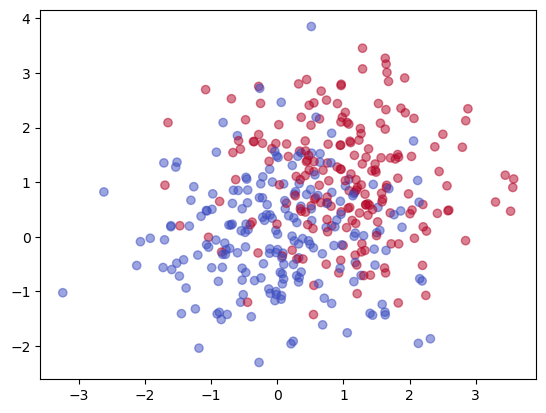

In [8]:
x, y = make_blobs(n_samples=500, centers=[(0,0), (1,1)], random_state=42)
y[y == 0] = -1
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = SVC(kernel="linear") #probati i druge modele, nekad nije prvi najbolji
model.fit(X_train, y_train)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', alpha=0.5)
#plt.show()

cm = confusion_matrix(y_test, model.predict(X_test))
#sbn.heatmap(cm, annot=True, fmt='d', cmap='Blues')

accuracy = model.score(X_test, y_test)
precision = cm[1, 1] / (cm[0, 1] + cm[1, 1])
recall = cm[1, 1] / (cm[1, 0] + cm[1, 1])
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')

## Klasifikacija sa više klasa
Problem koji ćemo pokušati riješiti je klasifikacija znamenaka. Svaki podatak je slika na kojoj se nalazi jedna znamenka i pripadna znamenka.

### One-vs-Rest (OvR)

One-vs-Rest (OvR) je strategija za proširenje binarne klasifikacije na višeklasni problem.

Ideja:
Za problem s $k$ klasa treniramo $k$ zasebnih binarnih klasifikatora.  
Svaki klasifikator uči prepoznati **jednu klasu naspram svih ostalih**.

Za $i$-ti klasifikator vrijedi:
- pozitivna klasa: $y = 1$ ako je uzorak klase $i$
- negativna klasa: $y = -1$ ako uzorak pripada bilo kojoj drugoj klasi

Dakle, svaki model odgovara na pitanje:
> "Je li ovaj uzorak baš klasa $i$ ili nije?"

---

### Predikcija

Za novi uzorak $x$ izračunamo skor (ili vjerojatnost) za svaki od $k$ klasifikatora:

$$
h_{\theta_1}(x),\; h_{\theta_2}(x),\; \dots,\; h_{\theta_k}(x)
$$

Konačnu klasu biramo kao onu s najvećim skorom:

$$
\hat{y} = \arg\max_{i \in \{1, \dots, k\}} h_{\theta_i}(x)
$$

---

### Intuicija

Svaki klasifikator je "specijalist" za svoju klasu.  
Na kraju biramo onoga koji je **najsigurniji** u svoju odluku.

---

### Prednosti i nedostaci

**Prednosti:**
- jednostavna implementacija
- radi s bilo kojim binarnim klasifikatorom (npr. logistička regresija, SVM)

**Nedostaci:**
- modeli se treniraju neovisno (ne "vide" međusobne odnose klasa)
- može doći do nesigurnih predikcija ako više klasifikatora daje slične rezultate

In [9]:
#demo
X = np.array([[0], [1], [2], [3]])
y = np.array([0, 0, 1, 1])

clf1 = SVC(kernel='linear')
clf2 = SVC(probability=True, kernel='linear')
clf1.fit(X, y)
clf2.fit(X, y)

print(clf1.decision_function(X))
print(clf2.predict_proba(X))

[-1.5 -0.5  0.5  1.5]
[[0.74999967 0.25000033]
 [0.59013174 0.40986826]
 [0.40886133 0.59113867]
 [0.24999593 0.75000407]]


In [10]:
digits = load_digits() #slike su 8x8 i greyscale, target su brojevi od 0 do 9

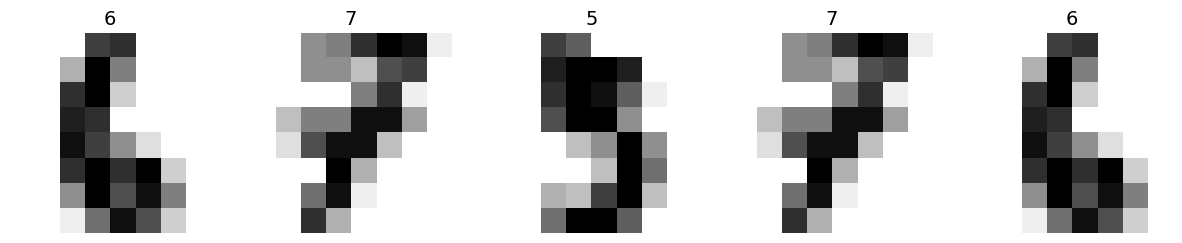

In [11]:
fig, axs = plt.subplots(nrows=1, ncols=5,figsize=(15,15))
for ax in axs:
    x = np.random.randint(9)
    ax.imshow(digits.data[x].reshape(8,8), cmap=plt.cm.binary)
    ax.set_xlabel('x-label', fontsize=12)
    ax.set_ylabel('y-label', fontsize=12)
    ax.set_title(digits.target[x], fontsize=14)
    ax.axis('off')

In [12]:
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.2)

In [13]:
def train(X,y,digit):
    clf = SVC(probability=True, kernel='linear')
    y=np.array([1 if i ==digit else -1 for i in y])
    clf.fit(X,y)
    return clf
def predict(X, models):
    predictions = np.zeros((X.shape[0], 10))
    for i, model in enumerate(models):
        pred = model.predict(X)[:,1] # ugradjena metoda, vraca 2 klase s 2 vjerojatnosti
        predictions[:, i] = pred
    return np.argmax(predictions, axis=1)


In [14]:
models =[]
for digit in range(10):
    model = train(X_train, y_train, digit)
    models.append(model)
    y_pred = predict(X_test, models)
    np.sum(y_pred == y_test) / len(y_test) # suma tocnih podataka

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

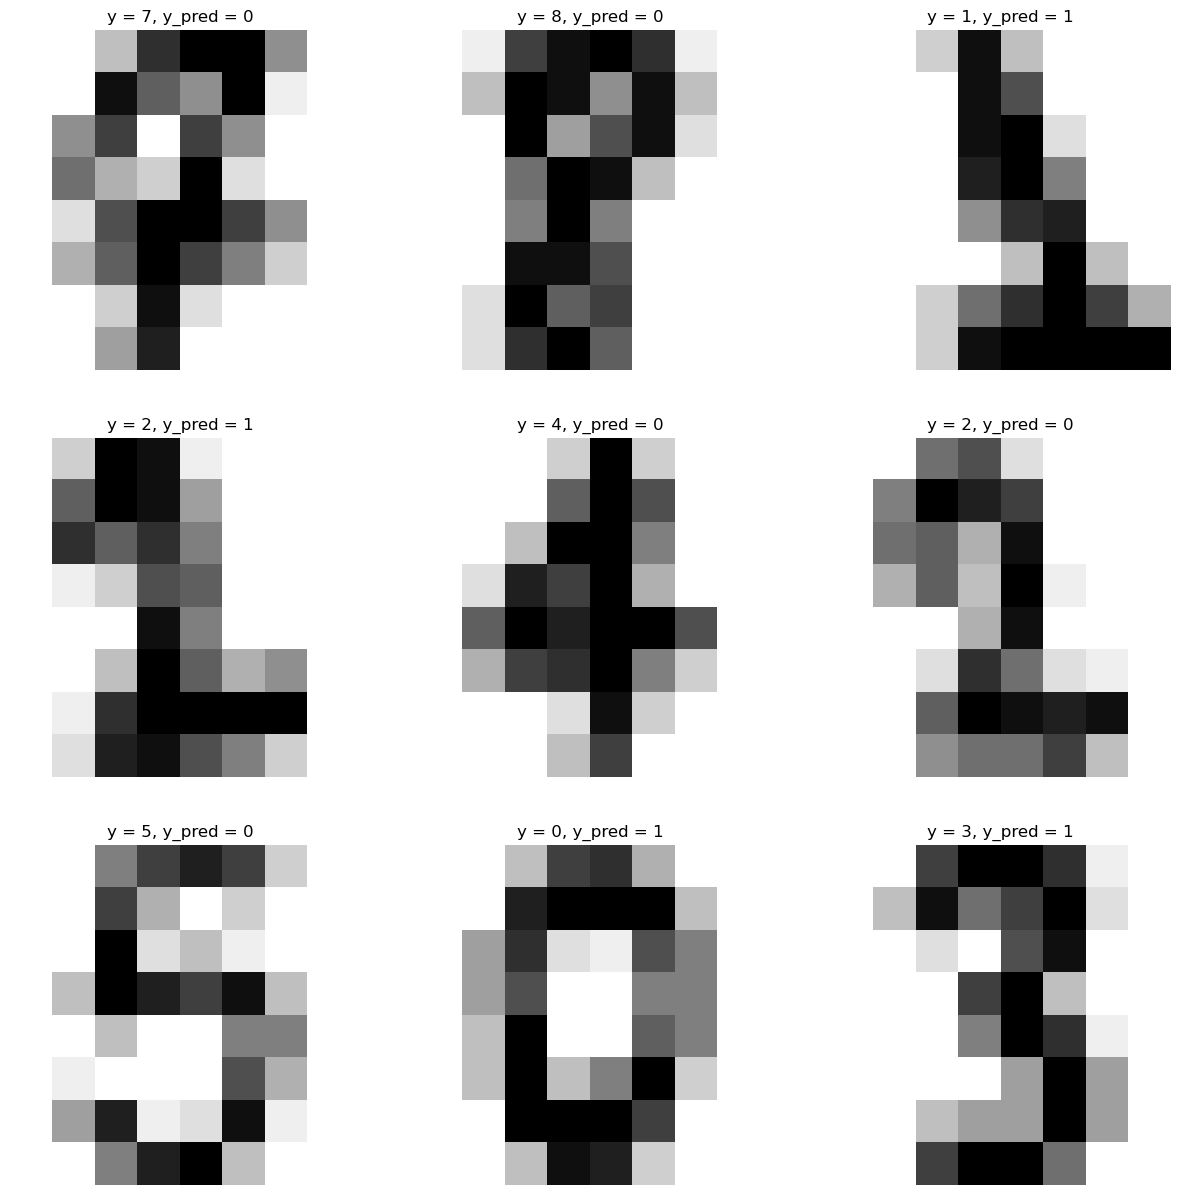

In [15]:
fig, axs = plt.subplots(nrows=3, ncols=3,figsize=(15,15))
for i, ax in enumerate(axs.flat):
    ax.imshow(X_test[i].reshape(8,8), cmap=plt.cm.binary)
    ax.set_title(f'y = {y_test[i]}, y_pred = {y_pred[i]}')
    ax.axis('off')

### One-vs-One (OvO)

One-vs-One (OvO) je strategija za rješavanje višeklasne klasifikacije tako da se trenira klasifikator za svaku par klasa.

Za problem s $k$ klasa trenira se ukupno:

$$
\frac{k(k-1)}{2}
$$

binarnih klasifikatora.

Svaki klasifikator je zadužen za razlikovanje između **dvije klase $i$ i $j$**.

Za klasifikator $(i, j)$:
- trenira se samo na podacima koji pripadaju klasama $i$ i $j$
- ostale klase se ignoriraju

---

### Ideja

Svaki model odgovara na pitanje:

> "Pripada li uzorak klasi $i$ ili klasi $j$?"

Za novi uzorak $x$, svaki klasifikator daje odluku (ili skor) između dvije klase.

---

### Predikcija

Za novi uzorak $x$ svi modeli “glasaju”:

- svaki model $(i, j)$ daje glas jednoj od te dvije klase
- svaka klasa skuplja broj glasova

Konačna predikcija je klasa s najviše glasova:

$$
\hat{y} = \arg\max_{i} \; \text{broj glasova za klasu } i
$$

---

### Intuicija

- OvR: jedan model po klasi (klasa vs svi)
- OvO: modeli u parovima (klasa vs klasa)

Svaki model je specijaliziran za razlikovanje **samo dvije klase**, što može dovesti do preciznijih granica odlučivanja.

---

### Prednosti i nedostaci

**Prednosti:**
- svaki model trenira na manjem podskupu podataka
- često bolja separacija između klasa
- modeli su jednostavniji (binarni problemi)

**Nedostaci:**
- potrebno trenirati mnogo modela: $\frac{k(k-1)}{2}$
- predikcija zahtijeva agregaciju glasova svih modela
- složenija implementacija od OvR

In [16]:
%%timeit
ovo = OneVsOneClassifier(SVC(random_state=123)).fit(X_train, y_train)

55.7 ms ± 436 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [17]:
%%timeit
ovr = OneVsRestClassifier(SVC(random_state=123)).fit(X_train, y_train)

80.6 ms ± 1.68 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


### Ugrađena višeklasna klasifikacija
U ugrađenom SVM solveru su dostupne OvO i OvR strategije.

U modelu logističke regresije dostupni su OvO i multinomna strategija.

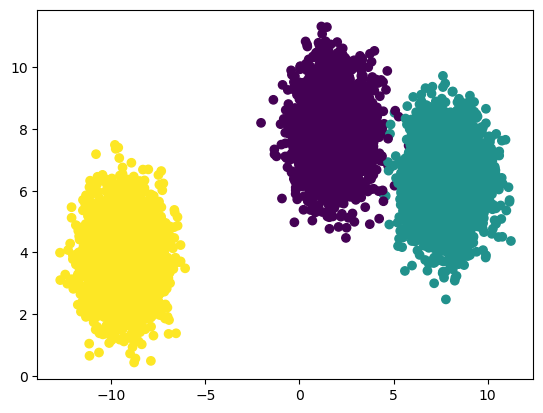

In [31]:
X,y = make_blobs(n_samples=10000, centers=3, random_state=20)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis')

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
clf = SVC(kernel='linear')
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.9986666666666667

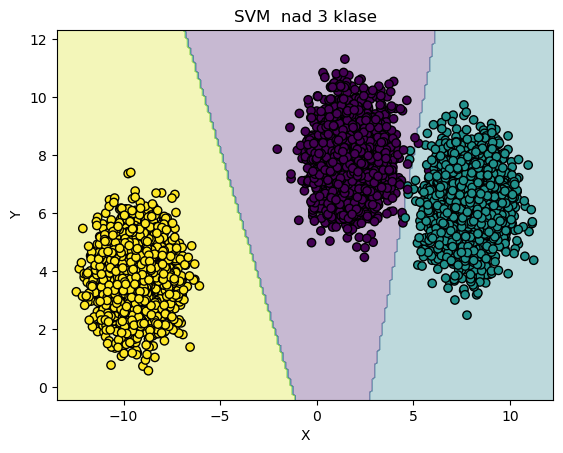

In [33]:
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = clf.predict(grid)
Z = Z.reshape(xx.shape)


plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("SVM  nad 3 klase")

plt.show()

In [34]:
clf = LogisticRegression().fit(X_train, y_train)
clf.score(X_test, y_test)

0.9986666666666667

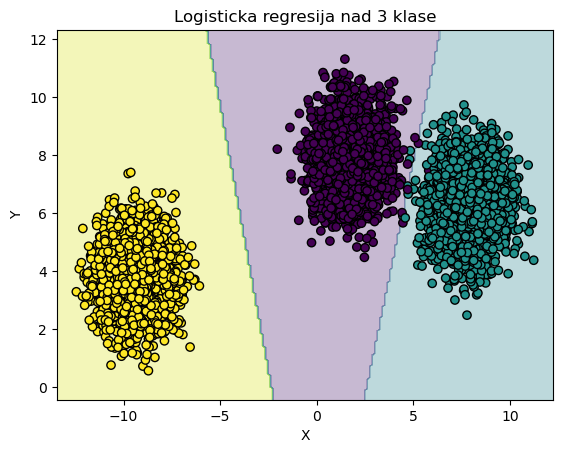

In [35]:
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = clf.predict(grid)
Z = Z.reshape(xx.shape)


plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Logisticka regresija nad 3 klase")

plt.show()